In [1]:
!pip install category_encoders -q

from category_encoders import TargetEncoder

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.7 MB/s eta 0:00:00


In [2]:
!pip install lightgbm -q


####Import Libraries

In [4]:
import gc
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from tqdm.auto import tqdm

plt.style.use("default")
sns.set_theme(style="whitegrid")


####Configuration

In [5]:
SEED = 42
TARGET = "Listening_Time_minutes"

MAX_PAIR_SIZE = 3
N_SPLITS_TE = 5
N_SPLITS_MODEL = 3
SMOOTH = 20.0

RUN_CV = True
SAVE_SUBMISSION = True

np.random.seed(SEED)

####Mappings

In [6]:
podc_dict = {
    'Mystery Matters': 0, 'Joke Junction': 1, 'Study Sessions': 2, 'Digital Digest': 3,
    'Mind & Body': 4, 'Fitness First': 5, 'Criminal Minds': 6, 'News Roundup': 7,
    'Daily Digest': 8, 'Music Matters': 9, 'Sports Central': 10, 'Melody Mix': 11,
    'Game Day': 12, 'Gadget Geek': 13, 'Global News': 14, 'Tech Talks': 15,
    'Sport Spot': 16, 'Funny Folks': 17, 'Sports Weekly': 18, 'Business Briefs': 19,
    'Tech Trends': 20, 'Innovators': 21, 'Health Hour': 22, 'Comedy Corner': 23,
    'Sound Waves': 24, 'Brain Boost': 25, "Athlete's Arena": 26, 'Wellness Wave': 27,
    'Style Guide': 28, 'World Watch': 29, 'Humor Hub': 30, 'Money Matters': 31,
    'Healthy Living': 32, 'Home & Living': 33, 'Educational Nuggets': 34,
    'Market Masters': 35, 'Learning Lab': 36, 'Lifestyle Lounge': 37,
    'Crime Chronicles': 38, 'Detective Diaries': 39, 'Life Lessons': 40,
    'Current Affairs': 41, 'Finance Focus': 42, 'Laugh Line': 43,
    'True Crime Stories': 44, 'Business Insights': 45, 'Fashion Forward': 46,
    'Tune Time': 47
}

genr_dict = {
    'True Crime': 0, 'Comedy': 1, 'Education': 2, 'Technology': 3, 'Health': 4,
    'News': 5, 'Music': 6, 'Sports': 7, 'Business': 8, 'Lifestyle': 9
}

week_dict = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3,
    'Friday': 4, 'Saturday': 5, 'Sunday': 6
}

time_dict = {
    'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3
}

sent_dict = {
    'Negative': 0, 'Neutral': 1, 'Positive': 2
}


####Load Data

In [7]:
train_df = pd.read_csv("train.csv", index_col="id")
test_df = pd.read_csv("test.csv", index_col="id")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

Train shape: (750000, 11)
Test shape: (250000, 10)


,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
id,,,,,,,,,,,
0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


####Quick Data Analysis

In [8]:
display(train_df.head())
print("\nInfo:")
train_df.info()

print("\nMissing values in train:")
display(train_df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nTarget summary:")
display(train_df[TARGET].describe().to_frame().T)

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
id,,,,,,,,,,,
0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031



Info:
<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Podcast_Name                 750000 non-null  object 
 1   Episode_Title                750000 non-null  object 
 2   Episode_Length_minutes       662907 non-null  float64
 3   Genre                        750000 non-null  object 
 4   Host_Popularity_percentage   750000 non-null  float64
 5   Publication_Day              750000 non-null  object 
 6   Publication_Time             750000 non-null  object 
 7   Guest_Popularity_percentage  603970 non-null  float64
 8   Number_of_Ads                749999 non-null  float64
 9   Episode_Sentiment            750000 non-null  object 
 10  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), object(6)
memory usage: 68.7+ MB

Missing values in train:


,missing
Guest_Popularity_percentage,146030
Episode_Length_minutes,87093
Number_of_Ads,1
Episode_Title,0
Podcast_Name,0
Genre,0
Host_Popularity_percentage,0
Publication_Time,0
Publication_Day,0
Episode_Sentiment,0



Target summary:


,count,mean,std,min,25%,50%,75%,max
Listening_Time_minutes,750000.0,45.437406,27.138306,0.0,23.17835,43.37946,64.81158,119.97


####Target Distribution

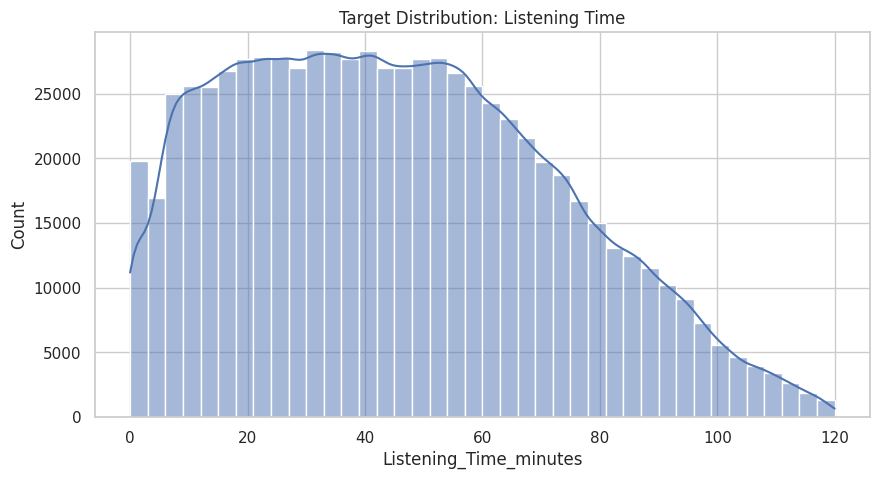

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(train_df[TARGET], bins=40, kde=True)
plt.title("Target Distribution: Listening Time")
plt.xlabel(TARGET)
plt.ylabel("Count")
plt.show()

####Numeric Features vs Target

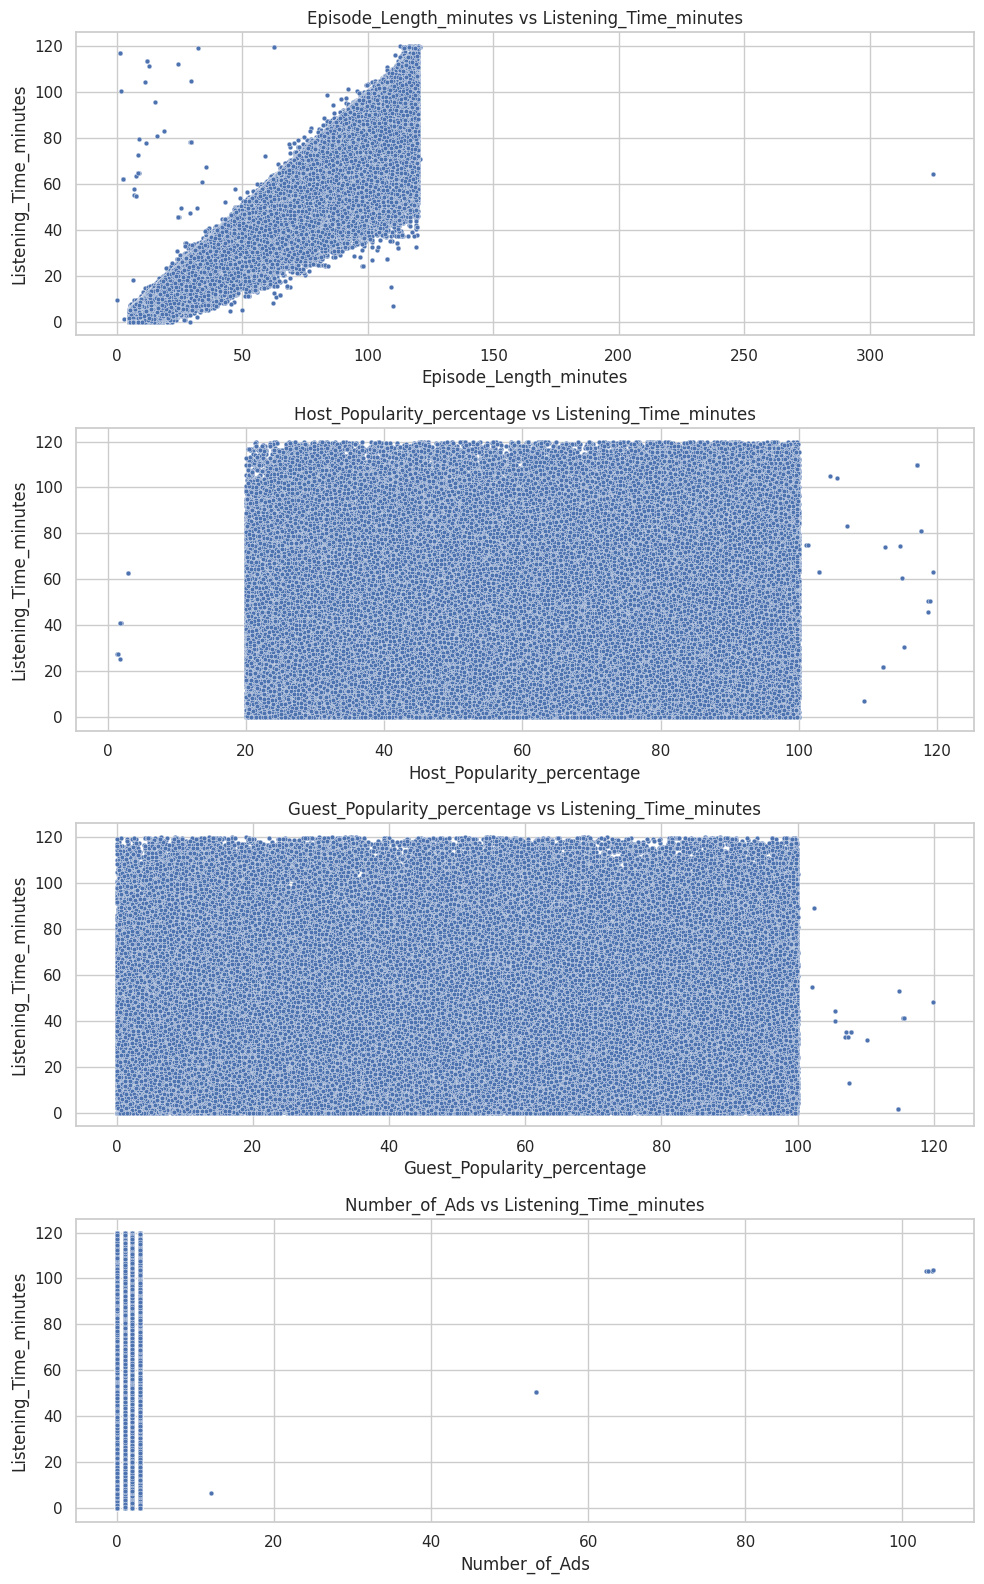

In [10]:
numeric_preview = [
    c for c in train_df.select_dtypes(include=np.number).columns
    if c != TARGET
]

fig, axes = plt.subplots(len(numeric_preview), 1, figsize=(10, 4 * len(numeric_preview)))
if len(numeric_preview) == 1:
    axes = [axes]

for ax, col in zip(axes, numeric_preview):
    sns.scatterplot(data=train_df, x=col, y=TARGET, ax=ax, s=12)
    ax.set_title(f"{col} vs {TARGET}")

plt.tight_layout()
plt.show()

####Category Counts

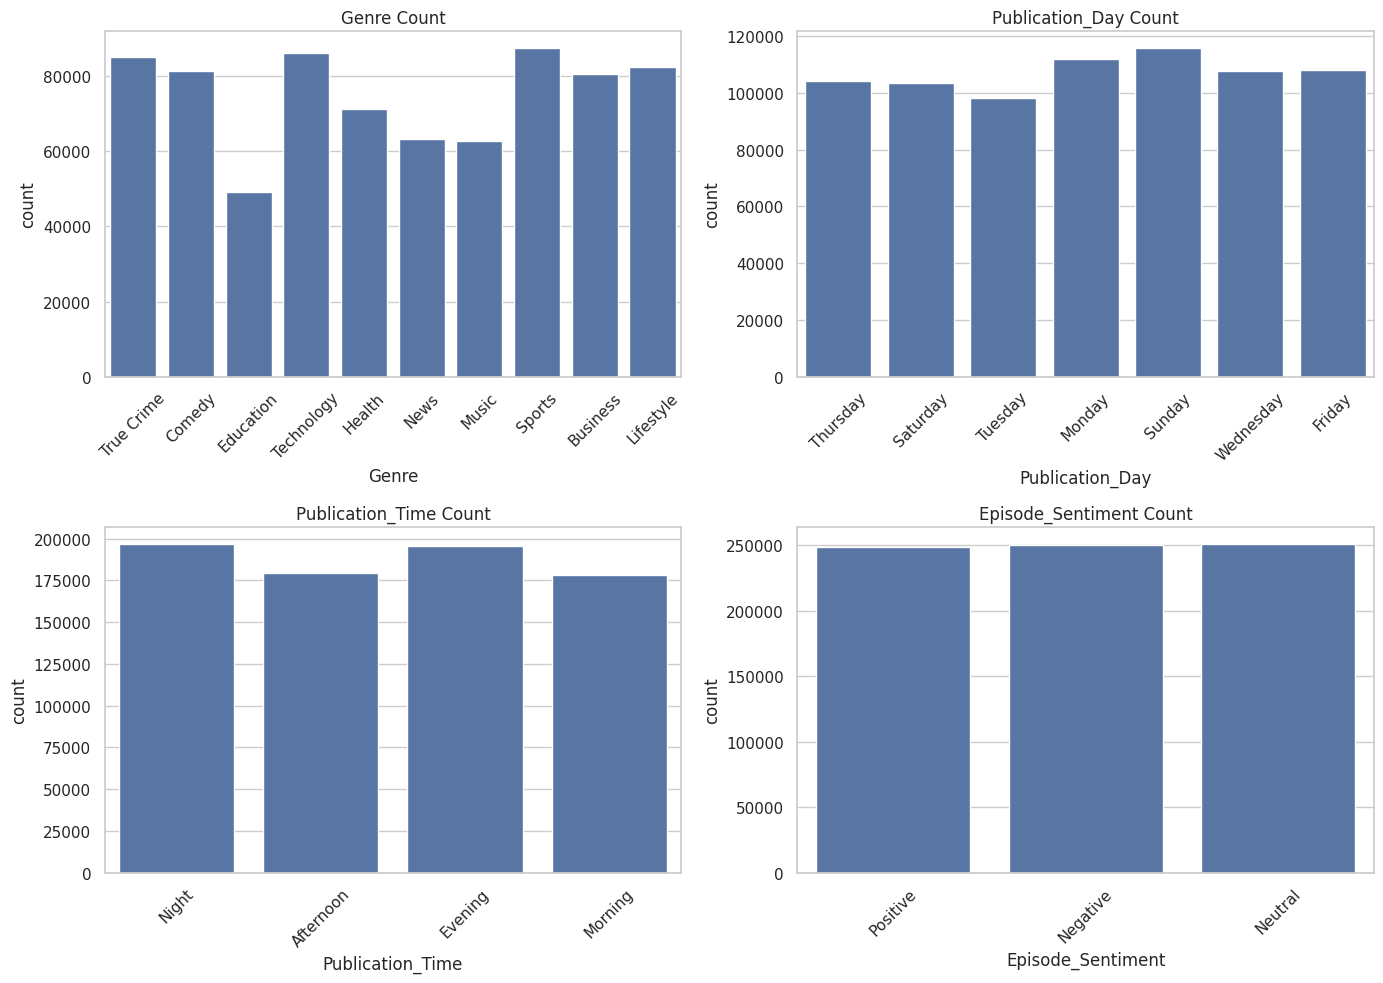

In [11]:
cat_preview = ["Genre", "Publication_Day", "Publication_Time", "Episode_Sentiment"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, cat_preview):
    if col in train_df.columns:
        sns.countplot(data=train_df, x=col, ax=ax)
        ax.set_title(f"{col} Count")
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

####Correlation Heatmap

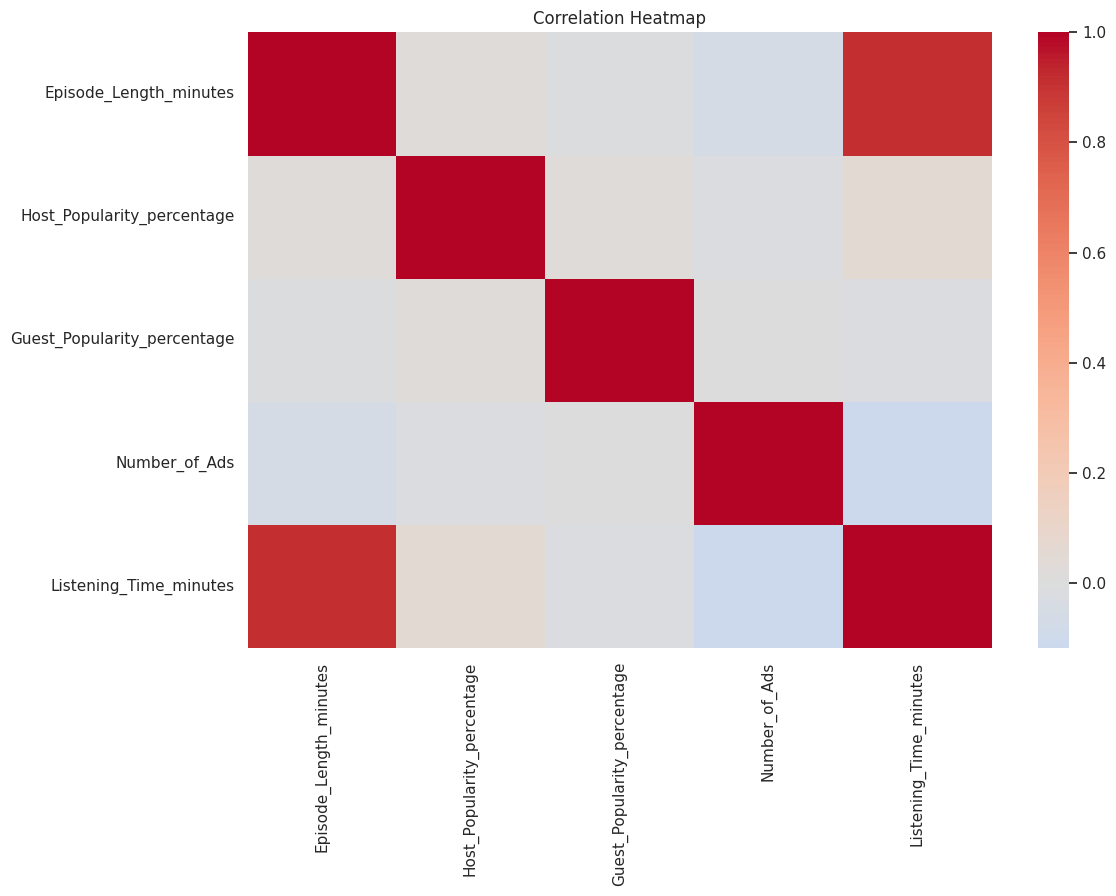

In [12]:
num_cols = train_df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12, 8))
sns.heatmap(train_df[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

####Feature Engineering

In [13]:
def feature_eng(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    numeric_cols = [
        "Episode_Length_minutes",
        "Host_Popularity_percentage",
        "Guest_Popularity_percentage",
        "Number_of_Ads"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

    for col in numeric_cols:
        med = df[col].median()
        if pd.isna(med):
            med = 0
        df[col] = df[col].fillna(med)

    df["Genre"] = df["Genre"].map(genr_dict).fillna(-1).astype(int).astype("category")
    df["Podcast_Name"] = df["Podcast_Name"].map(podc_dict).fillna(-1).astype(int).astype("category")
    df["Publication_Day"] = df["Publication_Day"].map(week_dict).fillna(-1).astype(int).astype("category")
    df["Publication_Time"] = df["Publication_Time"].map(time_dict).fillna(-1).astype(int).astype("category")
    df["Episode_Sentiment"] = df["Episode_Sentiment"].map(sent_dict).fillna(-1).astype(int).astype("category")

    df["Episode_Num"] = (
        df["Episode_Title"]
        .astype(str)
        .str.extract(r"(\\d+)", expand=False)
        .fillna(-1)
        .astype(int)
        .astype("category")
    )

    ep_len_round = df["Episode_Length_minutes"].round()
    host = df["Host_Popularity_percentage"]
    guest = df["Guest_Popularity_percentage"]

    df["Mul_Hpp_Elm"] = host * ep_len_round
    df["Mul_Gpp_Elm"] = guest * ep_len_round

    df["Rounded_Episode_Length_minutes"] = np.floor(ep_len_round / 2).astype("int64")
    df["Rounded_Host_Popularity_percentage"] = np.floor(host.round() / 2).astype("int64")
    df["Rounded_Guest_Popularity_percentage"] = np.floor(guest.round() / 2).astype("int64")

    df["Host_x_Guest"] = host * guest
    df["Ads_per_Minute"] = df["Number_of_Ads"] / (df["Episode_Length_minutes"] + 1.0)

    df = df.drop(columns=["Episode_Title"])
    return df

train_df = feature_eng(train_df)
test_df = feature_eng(test_df)

print(train_df.shape, test_df.shape)

/tmp/ipykernel_792/2510160987.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(-1)


(750000, 18) (250000, 17)


/tmp/ipykernel_792/2510160987.py:31: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(-1)


####Missing Value Handling

In [14]:
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]

train_medians = train_df[num_cols].median()

for c in num_cols:
    train_df[c] = train_df[c].fillna(train_medians[c])
    test_df[c] = test_df[c].fillna(train_medians[c])

cat_cols = train_df.select_dtypes(include=["category"]).columns.tolist()
for c in cat_cols:
    if c in train_df.columns:
        if -1 not in train_df[c].cat.categories:
            train_df[c] = train_df[c].cat.add_categories([-1])
        if -1 not in test_df[c].cat.categories:
            test_df[c] = test_df[c].cat.add_categories([-1])

        train_df[c] = train_df[c].fillna(-1)
        test_df[c] = test_df[c].fillna(-1)

print("Missing after handling:")
display(train_df.isna().sum().sort_values(ascending=False).to_frame("missing").head(10))


Missing after handling:


,missing
Podcast_Name,0
Episode_Length_minutes,0
Genre,0
Host_Popularity_percentage,0
Publication_Day,0
Publication_Time,0
Guest_Popularity_percentage,0
Number_of_Ads,0
Episode_Sentiment,0
Listening_Time_minutes,0


####Target Encoding Helpers

In [15]:
def make_combo_key(df: pd.DataFrame, cols) -> pd.Series:
    cols = list(cols)
    return df[cols].astype(str).agg("__".join, axis=1)


def oof_target_encode_combo(
    train: pd.DataFrame,
    test: pd.DataFrame,
    cols,
    target: str,
    n_splits: int = 5,
    smooth: float = 20.0,
    random_state: int = 42,
    new_col_name: str = None
):
    train = train.copy()
    test = test.copy()

    cols = list(cols)
    if new_col_name is None:
        new_col_name = "TE_" + "__".join(cols)

    train_keys = make_combo_key(train, cols)
    test_keys = make_combo_key(test, cols)

    global_mean = train[target].mean()
    oof_encoded = np.zeros(len(train), dtype=np.float32)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for tr_idx, val_idx in kf.split(train):
        tr_keys = train_keys.iloc[tr_idx]
        tr_y = train.iloc[tr_idx][target]

        tmp = pd.DataFrame({"key": tr_keys, "target": tr_y})
        stats = tmp.groupby("key")["target"].agg(["mean", "count"])
        enc_map = (stats["count"] * stats["mean"] + smooth * global_mean) / (stats["count"] + smooth)

        oof_encoded[val_idx] = (
            train_keys.iloc[val_idx]
            .map(enc_map)
            .fillna(global_mean)
            .astype(np.float32)
            .values
        )

    full_tmp = pd.DataFrame({"key": train_keys, "target": train[target]})
    full_stats = full_tmp.groupby("key")["target"].agg(["mean", "count"])
    full_map = (full_stats["count"] * full_stats["mean"] + smooth * global_mean) / (full_stats["count"] + smooth)

    test_encoded = (
        test_keys.map(full_map)
        .fillna(global_mean)
        .astype(np.float32)
        .values
    )

    train[new_col_name] = oof_encoded
    test[new_col_name] = test_encoded

    return train, test, new_col_name


def add_te_stats(train: pd.DataFrame, test: pd.DataFrame, encoded_cols_by_r: dict):
    train = train.copy()
    test = test.copy()

    all_te_cols = []
    for r in encoded_cols_by_r:
        all_te_cols.extend(encoded_cols_by_r[r])

    all_te_cols = list(dict.fromkeys(all_te_cols))

    train["te_global_mean"] = train[all_te_cols].mean(axis=1)
    train["te_global_std"] = train[all_te_cols].std(axis=1)
    train["te_global_min"] = train[all_te_cols].min(axis=1)
    train["te_global_max"] = train[all_te_cols].max(axis=1)

    test["te_global_mean"] = test[all_te_cols].mean(axis=1)
    test["te_global_std"] = test[all_te_cols].std(axis=1)
    test["te_global_min"] = test[all_te_cols].min(axis=1)
    test["te_global_max"] = test[all_te_cols].max(axis=1)

    for r, cols_r in encoded_cols_by_r.items():
        if len(cols_r) == 0:
            continue

        train[f"te_mean_r{r}"] = train[cols_r].mean(axis=1)
        train[f"te_std_r{r}"] = train[cols_r].std(axis=1)
        train[f"te_min_r{r}"] = train[cols_r].min(axis=1)
        train[f"te_max_r{r}"] = train[cols_r].max(axis=1)

        test[f"te_mean_r{r}"] = test[cols_r].mean(axis=1)
        test[f"te_std_r{r}"] = test[cols_r].std(axis=1)
        test[f"te_min_r{r}"] = test[cols_r].min(axis=1)
        test[f"te_max_r{r}"] = test[cols_r].max(axis=1)

    return train, test


####Target Encoding


In [17]:
encode_columns = [
    "Podcast_Name",
    "Episode_Length_minutes",
    "Episode_Num",
    "Episode_Sentiment",
    "Host_Popularity_percentage",
    "Guest_Popularity_percentage",
    "Number_of_Ads",
    "Publication_Day",
    "Publication_Time",
    "Rounded_Episode_Length_minutes",
    "Rounded_Host_Popularity_percentage",
    "Rounded_Guest_Popularity_percentage",
    "Genre",
]

encoded_cols_by_r = {r: [] for r in range(1, MAX_PAIR_SIZE + 1)}

for r in range(1, MAX_PAIR_SIZE + 1):
    print(f"\n=== Target encoding pair_size = {r} ===")
    for cols in tqdm(list(combinations(encode_columns, r))):
        invalid = (
            (("Rounded_Episode_Length_minutes" in cols) and ("Episode_Length_minutes" in cols)) or
            (("Rounded_Host_Popularity_percentage" in cols) and ("Host_Popularity_percentage" in cols)) or
            (("Rounded_Guest_Popularity_percentage" in cols) and ("Guest_Popularity_percentage" in cols))
        )
        if invalid:
            continue

        new_name = f"TE_r{r}_" + "_".join(cols)

        train_df, test_df, created_col = oof_target_encode_combo(
            train=train_df,
            test=test_df,
            cols=cols,
            target=TARGET,
            n_splits=N_SPLITS_TE,
            smooth=SMOOTH,
            random_state=SEED,
            new_col_name=new_name
        )
        encoded_cols_by_r[r].append(created_col)

        gc.collect()

train_df, test_df = add_te_stats(train_df, test_df, encoded_cols_by_r)
print("TE done.")



=== Target encoding pair_size = 1 ===


  0%|          | 0/13 [00:00<?, ?it/s]


=== Target encoding pair_size = 2 ===


  0%|          | 0/78 [00:00<?, ?it/s]


=== Target encoding pair_size = 3 ===


  0%|          | 0/286 [00:00<?, ?it/s]

TE done.


#### Prepare Matrices

In [18]:
X = train_df.drop(columns=[TARGET])
y = train_df[TARGET].copy()
X_test = test_df.copy()

cat_features = X.select_dtypes(include=["category"]).columns.tolist()
print("X shape:", X.shape)
print("X_test shape:", X_test.shape)
print("Categorical features:", cat_features[:10], "..." if len(cat_features) > 10 else "")


X shape: (750000, 374)
X_test shape: (250000, 374)
Categorical features: ['Podcast_Name', 'Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment', 'Episode_Num'] 


####LightGBM Parameters

In [19]:
params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.03,
    "n_estimators": 4000,
    "max_depth": 15,
    "num_leaves": 480,
    "colsample_bytree": 0.25,
    "subsample": 0.85,
    "subsample_freq": 1,
    "min_data_in_leaf": 35,
    "reg_alpha": 0.2,
    "reg_lambda": 1.5,
    "random_state": SEED,
    "verbosity": -1,
    "force_col_wise": True
}

####Cross Validation Training

In [20]:
oof = np.zeros(len(X), dtype=np.float32)
test_pred = np.zeros(len(X_test), dtype=np.float32)

kf = KFold(n_splits=N_SPLITS_MODEL, shuffle=True, random_state=SEED)

for fold, (tr_idx, va_idx) in enumerate(kf.split(X, y), 1):
    print(f"Fold:{fold}")

    X_tr = X.iloc[tr_idx].copy()
    y_tr = y.iloc[tr_idx].copy()
    X_va = X.iloc[va_idx].copy()
    y_va = y.iloc[va_idx].copy()

    model = lgb.LGBMRegressor(**params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="rmse",
        categorical_feature=cat_features if len(cat_features) > 0 else "auto",
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )

    pred_va = model.predict(X_va, num_iteration=model.best_iteration_)
    pred_te = model.predict(X_test, num_iteration=model.best_iteration_)

    oof[va_idx] = pred_va
    test_pred += pred_te / N_SPLITS_MODEL

    fold_rmse = np.sqrt(mean_squared_error(y_va, pred_va))
    print(f"Fold {fold} RMSE = {fold_rmse:.6f} | Best iter = {model.best_iteration_}")

cv_rmse = np.sqrt(mean_squared_error(y, oof))
print(f"\nOOF RMSE = {cv_rmse:.6f}")


Fold:1
[200]	valid_0's rmse: 12.3391
[400]	valid_0's rmse: 12.3014
[600]	valid_0's rmse: 12.2926
[800]	valid_0's rmse: 12.2899
Fold 1 RMSE = 12.288382 | Best iter = 836
Fold:2
[200]	valid_0's rmse: 12.3556
[400]	valid_0's rmse: 12.3217
[600]	valid_0's rmse: 12.3108
[800]	valid_0's rmse: 12.3047
[1000]	valid_0's rmse: 12.3021
Fold 2 RMSE = 12.301525 | Best iter = 914
Fold:3
[200]	valid_0's rmse: 12.3258
[400]	valid_0's rmse: 12.2904
[600]	valid_0's rmse: 12.2749
[800]	valid_0's rmse: 12.2647
[1000]	valid_0's rmse: 12.2595
[1200]	valid_0's rmse: 12.257
[1400]	valid_0's rmse: 12.2558
Fold 3 RMSE = 12.255499 | Best iter = 1359

OOF RMSE = 12.281817


####Save Submission

In [21]:
submission = pd.DataFrame({
    "id": X_test.index,
    TARGET: test_pred
})

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
display(submission.head())

try:
    from google.colab import files
    files.download("submission.csv")
except Exception:
    pass

Saved submission.csv


,id,Listening_Time_minutes
0,750000,55.124344
1,750001,19.604012
2,750002,47.812939
3,750003,82.323807
4,750004,51.196686


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>